# Assignement 2 Metabolic whatnot

In [ ]:
!pip install cobra
import cobra
import csv
import pandas as pd
## https://escher.github.io/#/app?map=e_coli_core.Core%20metabolism&tool=Builder&scrollToZoom=true&model=e_coli_core

## Task 1

### 1A:

In the interactive session, we saw reaction fluxes in a linear pathway being equal to each other due
to mass balance constraints. Do you observe the same thing now for the maximal reaction activities?

No, we do not observe the same thing. The reaction values in this dataset vary widely. These values range from 0.0 to 80.1 mol/gDW/h. Unlike the linear pathway oberved during the session, where where mass balance forces have identical fluxes (v_1 = v_2), this metabolic network is more akin to a real metabolic network (extensive branching, loops, etc.).



### ----------






### 1B:

Some reactions are shown with grey arrows, predominantly at the lower end of the map. These can
show one of two different values – identify what these values are and how their meaning differs.

The 2 different values are 0, and no data.

When a value is 0, it means that the reaction is present in the expression, however its maximal activity is 0. This is to show that the reaction has no availeble capacity

## Task 2:

We will now establish an enzyme activity-constrained metabolic model in COBRApy. Please
implement the maximal reaction activity data in the
E. coli core model from the practical per the below
instructions.
- For reversible reactions, set the lower and upper flux bound to -value and +value, respectively (“value”
as the maximal reaction activity).
- For irreversible reactions, only set the maximal flux bound to +value and leave the minimal flux bound
at zero.
- For reactions without data, leave their default constraints.
- For the glucose exchange reaction (“EX_glc__D_e”; see practical), please remove the pre-existing
maximal absolute flux bound and use the high absolute default bound instead.
- For the ATPM energy maintenance reaction (see practical), leave the lower flux as-is, since it describes
cellular energy requirements separate from any maximal reaction activities.
Please print a table listing each reaction’s lower and upper flux bound after implementing the above (no
formatting requirements, simple printout sufficient)

In [ ]:
model = cobra.io.load_json_model("e_coli_core.json")

# save atpm
atpm_lower = model.reactions.get_by_id("ATPM").lower_bound

# getting the maximum rection activity data

reaction_activity = {}

csvfile = "KEN3170_Assignment_2026_e_coli_core_expression.csv"

with open(csvfile, "r") as csvfile:
    reader = csv.reader(csvfile)
    next(reader)

    for row in reader:
        reaction_id = row[0].strip()
        value = float(row[1])
        reaction_activity[reaction_id] = value

for reaction_id, value in reaction_activity.items():
  reaction = model.reactions.get_by_id(reaction_id)
  # Reversible reaction
  if reaction.lower_bound < 0 and reaction.upper_bound > 0:
      reaction.lower_bound = -value
      reaction.upper_bound = value

    # Irreversible reaction
  else:
      reaction.lower_bound = 0
      reaction.upper_bound = value

# atpm lower flux
model.reactions.get_by_id("ATPM").lower_bound = atpm_lower


# glucose to default bounds
glucose = model.reactions.get_by_id("EX_glc__D_e")
glucose.lower_bound = -1000
glucose.upper_bound = 1000

data = []

# Printing table
for reaction in model.reactions:
    data.append({
        "Reaction": reaction.id,
        "Lower bound": reaction.lower_bound,
        "Upper bound": reaction.upper_bound
    })

df = pd.DataFrame(data)

print(df.to_string(index=False))

                Reaction  Lower bound  Upper bound
                     PFK         0.00        13.10
                     PFL         0.00         0.00
                     PGI       -11.10        11.10
                     PGK       -24.00        24.00
                     PGL         0.00         7.30
                   ACALD        -0.00         0.00
                  AKGt2r        -0.00         0.00
                     PGM       -21.70        21.70
                   PIt2r        -5.20         5.20
                  ALCD2x        -0.00         0.00
                  ACALDt     -1000.00      1000.00
                    ACKr        -2.50         2.50
                     PPC         0.00         3.60
                  ACONTa       -21.40        21.40
                  ACONTb       -21.40        21.40
                    ATPM         8.39      1000.00
                    PPCK         0.00        13.30
                   ACt2r        -3.60         3.60
                     PPS       

## Task 3:

In [ ]:
# carry out Flux Balance Analysis (FBA)
solution = model.optimize()

# report maximal biomass production rate
print(f"Maximal Biomass Production Rate: {solution.objective_value:.4f} mmol/gDW/h")

Maximal Biomass Production Rate: 0.8733 mmol/gDW/h


In [ ]:
# re-establish absolute flux bound on EX_glc__D_e
glucose = model.reactions.get_by_id("EX_glc__D_e")
glucose.lower_bound = -5.0
glucose.upper_bound = 5.0

Explain what this constraint would describe in contrast to the expression-based constraints implemented in the rest of the model.

Setting an absolute flux bound of 5 mmol/gDW/h on the glucose exchange reaction (EX\_glc\_\_D\_e) restricts the rate at which the cell can take up external glucose. This specific constraint models factors such as nutrient availability and transporter capacity. In contrast, gene expression constraints limit how fast internal enzymes can work based on how much of each protein is available inside the cell, rather than focusing on outside nutrients.



In [ ]:
# carry out FBA on new glucose bounds
solution = model.optimize()

# report new maximal biomass production rate
print(f"Maximal Biomass Production Rate: {solution.objective_value:.4f} mmol/gDW/h")

Maximal Biomass Production Rate: 0.4156 mmol/gDW/h


Using the new glucose bounds, explain any differences you observe in the predicted maximal biomass production rate.

The biomass rate dropped from 0.8733 mmol/gDW/h to 0.4156 mmol/gDW/h. This is because tightening the glucose upper limit to 5 mmol/gDW/h restricted the cell's carbon and energy supply. This shows that glucose was the limiting nutrient, as the lower external supply was directly bottlenecking the maximal growth rate.

# Task 4

First activated at glucose uptake = 9.40 mmol/gDW/h
Newly active exchange reaction(s): {'EX_ac_e': np.float64(0.05367170526640648)}


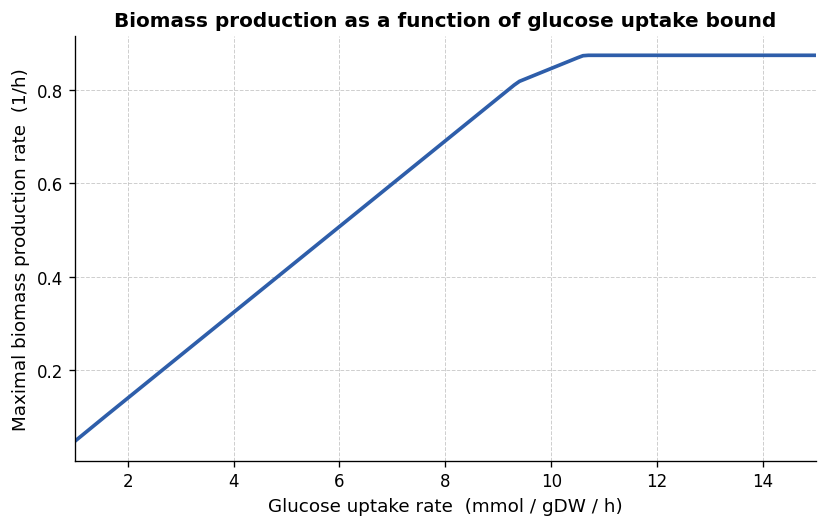

In [ ]:
# a) Prepare a plot of the maximal biomass production rate as a function of glucose exchange reaction
# flux bound in the interval [1,15] mmol/gDW/h (in uptake direction), in increments of 0.1 mmol/gDW/h.

biomasses = []
increment = 0.1
minimum = 1
maximum = 15
span = maximum - minimum
steps = int(round(span / increment)) + 1  # +1 so the endpoint (15.0) is included
allexfluxes = []

for i in range(0, steps):
    glucose.lower_bound = -(minimum + increment*i)
    solution = model.optimize()

    # record the flux of every exchange reaction for this run, as a dict {reaction_id: flux}
    ex_fluxes = {}
    for ex in model.exchanges:
        ex_fluxes[ex.id] = solution.fluxes[ex.id]
    allexfluxes.append(ex_fluxes)

    biomasses.append(solution.objective_value)

# find the first run where some exchange reaction switches on (was ~0 at the start, now isn't)
tol = 1e-6
runs = len(allexfluxes)
start_fluxes = allexfluxes[0]
limiting_fluxes = {}

for run in range(0, runs):
    found = False
    for reaction_id in start_fluxes:
        if abs(start_fluxes[reaction_id]) < tol and allexfluxes[run][reaction_id] > tol:
            found = True
            limiting_fluxes[reaction_id] = allexfluxes[run][reaction_id]

    if found:
        break

print(f"First activated at glucose uptake = {minimum + increment*run:.2f} mmol/gDW/h")
print("Newly active exchange reaction(s):", limiting_fluxes)


import matplotlib.pyplot as plt

x = [ minimum + increment*i for i in range(0, steps) ]

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=120)

ax.plot(x, biomasses, color="#2E5EAA", linewidth=2.2)

ax.set_xlabel("Glucose uptake rate  (mmol / gDW / h)", fontsize=11)
ax.set_ylabel("Maximal biomass production rate  (1/h)", fontsize=11)
ax.set_title("Biomass production as a function of glucose uptake bound", fontsize=12, fontweight="bold")

ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(min(x), max(x))
ax.margins(y=0.05)

fig.tight_layout()
plt.show()


## Part B

Does the growth rate increase indefinitely with increasing glucose exchange reaction flux bound?


No, it maxes out at around 11 mmol / (gDW * h) of glucose intake. The biomass production rate increases linearly as glucose intake goes from 1 until around 9, when an increase in glucose results in a proportionally lower increase in biomass production rate. The relationship is still linear, but the slope is smaller in the interval around 9 to 11. Then at 11 there is a plateau as mentioned.

This is likely due to bottlenecks in the metabolic path. By looking at Escher, I







## Part C

First activated at glucose uptake = 9.40 mmol/gDW/h
Newly active exchange reaction(s): {'EX_ac_e': np.float64(0.053671705266407514)



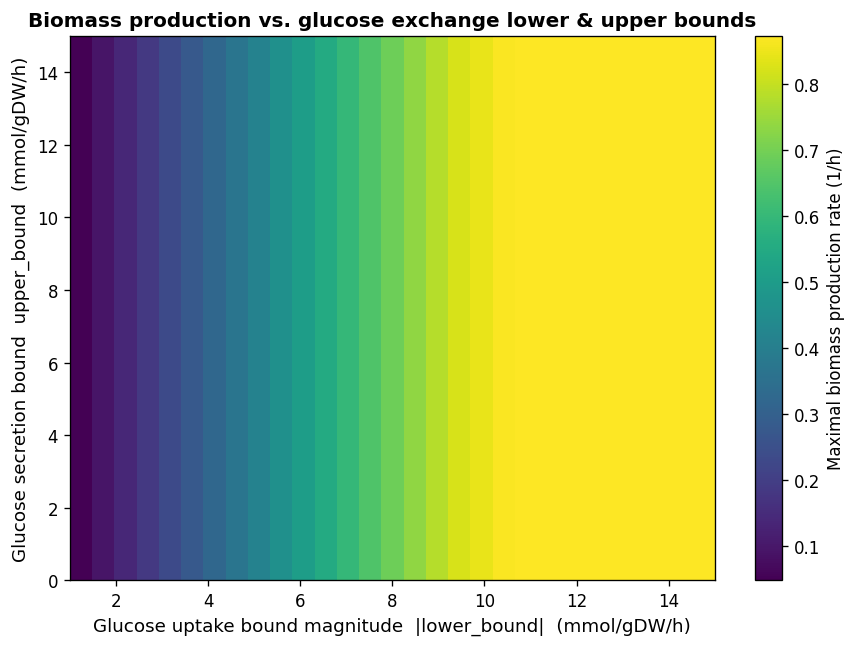

In [ ]:
# Bonus:
# Changing glucose secretion never changes the maximal biomass rate.
# The reason is that the optimiser will never pick a solution that secretes
# glucose, because it's suboptimal. So increasing the upper bound has no effect
# on the output. The following plots a heatmap that proves it:


# Heatmap: biomass as a function of BOTH the glucose exchange lower bound (uptake cap)
# and upper bound (secretion cap), varied independently.
# x-axis: uptake magnitude, i.e. |lower_bound|
# y-axis: upper_bound (secretion cap)
# color:  resulting maximal biomass production rate from FBA

import numpy as np
import matplotlib.pyplot as plt

increment = 0.5
lb_values = np.arange(1, 15 + increment, increment)   # x-axis: uptake magnitude -> lower_bound = -lb_values
ub_values = np.arange(0, 15 + increment, increment)   # y-axis: secretion cap -> upper_bound = ub_values

biomass_grid = np.full((len(ub_values), len(lb_values)), np.nan)

for i, ub in enumerate(ub_values):
    for j, lb in enumerate(lb_values):
        glucose.lower_bound = -lb
        glucose.upper_bound = ub
        sol = model.optimize()
        if sol.status == "optimal":
            biomass_grid[i, j] = sol.objective_value

fig, ax = plt.subplots(figsize=(7.5, 5.5), dpi=120)

im = ax.imshow(
    biomass_grid,
    origin="lower",
    aspect="auto",
    extent=[lb_values[0], lb_values[-1], ub_values[0], ub_values[-1]],
    cmap="viridis",
)

ax.set_xlabel("Glucose uptake bound magnitude  |lower_bound|  (mmol/gDW/h)", fontsize=11)
ax.set_ylabel("Glucose secretion bound  upper_bound  (mmol/gDW/h)", fontsize=11)
ax.set_title("Biomass production vs. glucose exchange lower & upper bounds", fontsize=12, fontweight="bold")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Maximal biomass production rate (1/h)", fontsize=10)

fig.tight_layout()
plt.show()

# restore a sensible default before continuing elsewhere in the notebook
glucose.lower_bound = -5.0
glucose.upper_bound = 5.0

